<a href="https://colab.research.google.com/github/Pam-Pam29/Summative_assignment_MLOP/blob/main/Notebook/PCOS_Detection_MLOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCOS Detection Using Ultrasound Images - MLOP Assignment

This notebook implements a deep learning model for detecting Polycystic Ovary Syndrome (PCOS) from ultrasound images using transfer learning.

## 1. Import Required Libraries

First, I import all the necessary libraries for data manipulation, visualization, and machine learning.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## 2. Install and Import Kaggle Package

I install the Kaggle package which will be used to download the dataset from Kaggle.


In [2]:
!pip install kaggle

## 3. Install TensorFlow and Import Deep Learning Libraries

I install TensorFlow and import all necessary deep learning components including Keras, ResNet50, and various layers and callbacks for building and training our model.


In [3]:
!pip install tensorflow>=2.20.0 -q

import tensorflow as tf
print(f" TensorFlow: {tf.__version__}")
print(f" Keras: {tf.keras.__version__}")

if not tf.__version__.startswith('2.19'):
    print(" ERROR: Wrong version! Restart runtime and try again.")
else:
    print(" Version correct - ready to train!")

 TensorFlow: 2.19.0
 Keras: 3.10.0
 Version correct - ready to train!


In [4]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout,
                                     BatchNormalization, Activation)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                       ReduceLROnPlateau, TensorBoard)
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score,
                             precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split

## 4. Import Plotly and Set Random Seeds

I import Plotly for interactive visualizations and set random seeds for reproducibility to ensure consistent results across runs.


In [5]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 5. Download Dataset from Kaggle



In [6]:
import kagglehub

path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")

print("Path to dataset files:", path)

100%|██████████| 126M/126M [00:06<00:00, 19.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1


## 6. Set Up Dataset Paths and Categories

I define the base path and categories for our dataset. The dataset contains two classes: "infected" (PCOS positive) and "noninfected" (PCOS negative).


In [7]:
base_path = path
categories = ["infected", "noninfected"]

## 7. Define Directory Paths

I set up the directory paths for training data, test data, and where we'll save our trained models.


In [8]:
BASE_DIR = Path(base_path) / "data"
categories = ["infected", "noninfected"]
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

## 8. Count Images in Dataset

I then create a function to count the number of images in each class (infected/noninfected) for both training and test sets. This helps us understand the dataset distribution.


In [9]:
def count_images(directory):
    counts = {}
    total = 0

    if directory.exists():
        for class_dir in directory.iterdir():
            if class_dir.is_dir():
                image_files = list(class_dir.glob('*.jpg')) + \
                             list(class_dir.glob('*.png')) + \
                             list(class_dir.glob('*.jpeg'))
                counts[class_dir.name] = len(image_files)
                total += len(image_files)
        counts['total'] = total

    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

## 9. Create DataFrame of Image Paths and Labels

I create a pandas DataFrame containing all image paths and their corresponding labels. This helps us organize and track our dataset.


In [10]:
image_paths = []
labels = []

for category in categories:
    for subset in ['test', 'train']:
        subset_path = os.path.join(base_path, subset, category)
        if os.path.exists(subset_path):
            for image_name in os.listdir(subset_path):
                image_path = os.path.join(subset_path, image_name)
                image_paths.append(image_path)
                labels.append(category)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

## 10. Dataset Statistics



In [11]:
print(f"\n Dataset Statistics:")
print(f"\nTraining Set:")
for key, value in train_counts.items():
    if key != 'total':
        print(f"   {key}: {value} images")
print(f"   Total: {train_counts.get('total', 0)} images")

print(f"\nTest Set:")
for key, value in test_counts.items():
    if key != 'total':
        print(f"   {key}: {value} images")
print(f"   Total: {test_counts.get('total', 0)} images")


 Dataset Statistics:

Training Set:
   infected: 781 images
   notinfected: 1143 images
   Total: 1924 images

Test Set:
   infected: 787 images
   notinfected: 1145 images
   Total: 1932 images


## 11. Visualize Class Distribution

I create charts to visualize the distribution of classes in both training and test sets. This helps us identify any class imbalance.


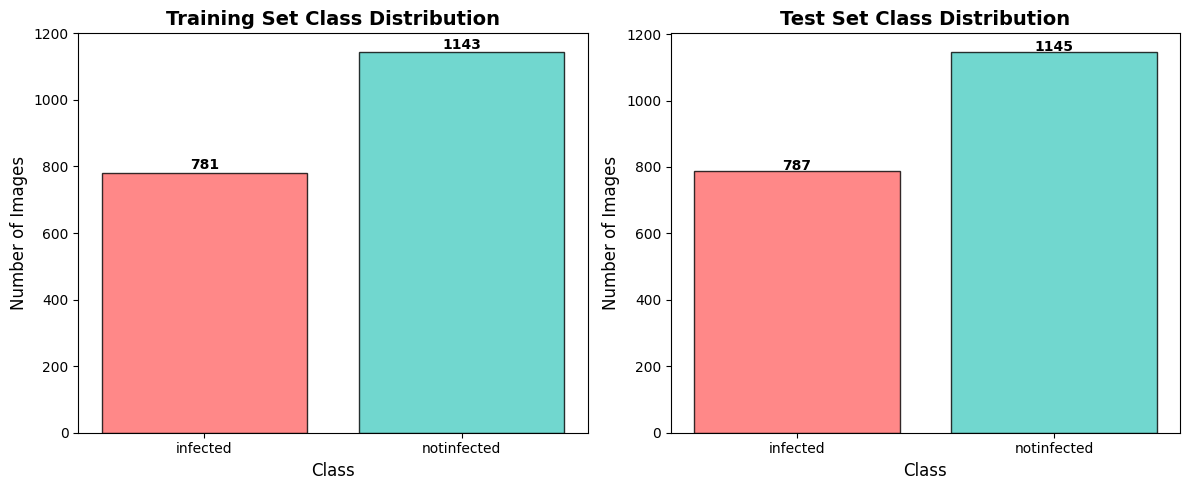

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
classes = [k for k in train_counts.keys() if k != 'total']
values = [train_counts[k] for k in classes]
colors = ['#ff6b6b', '#4ecdc4']

ax1.bar(classes, values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Images', fontsize=12)
ax1.set_xlabel('Class', fontsize=12)
for i, v in enumerate(values):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

test_classes = [k for k in test_counts.keys() if k != 'total']
test_values = [test_counts[k] for k in test_classes]

ax2.bar(test_classes, test_values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.set_xlabel('Class', fontsize=12)
for i, v in enumerate(test_values):
    ax2.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Display Sample Images

I create a function to display sample images from each class in the dataset. This basically helps to inspect the data and understand what the model will be learning from.


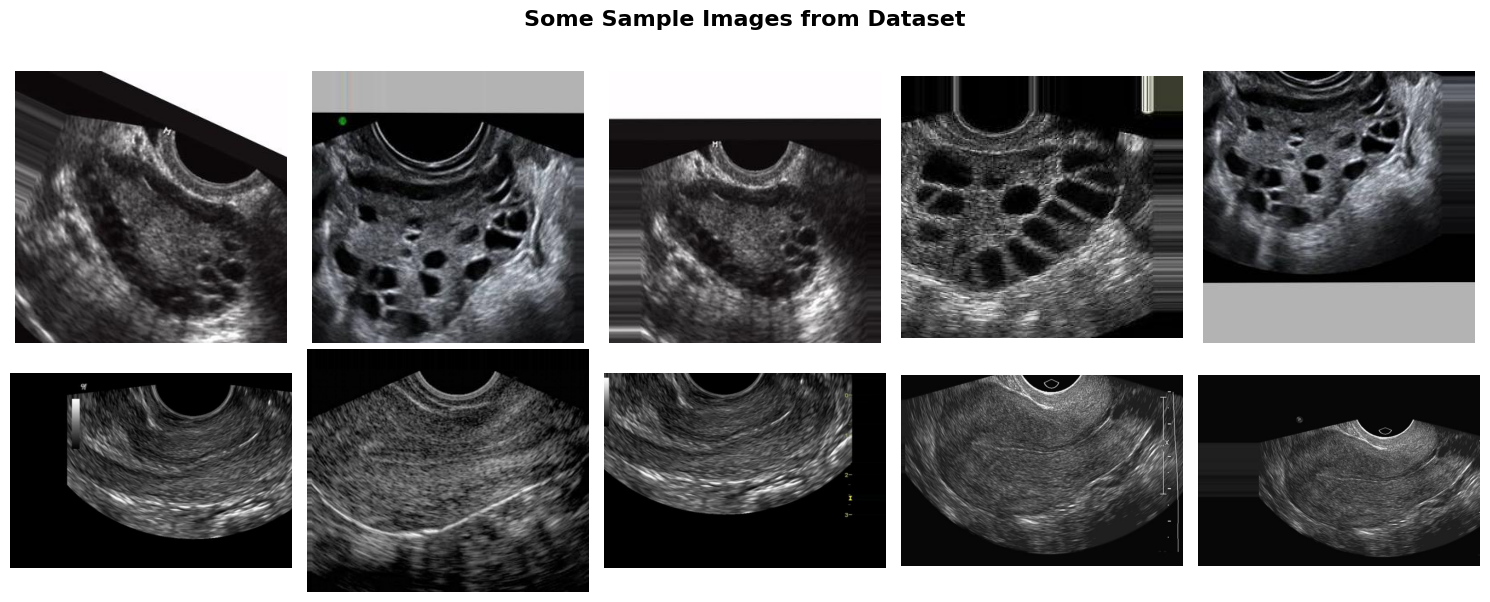

In [13]:
def display_sample_images(directory, samples_per_class=5):
    classes = [d.name for d in directory.iterdir() if d.is_dir()]

    fig, axes = plt.subplots(len(classes), samples_per_class,
                            figsize=(15, 6))
    fig.suptitle('Some Sample Images from Dataset', fontsize=16, fontweight='bold', y=1.02)

    for i, class_name in enumerate(classes):
        class_path = directory / class_name
        images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))

        samples = np.random.choice(images, min(samples_per_class, len(images)), replace=False)

        for j, img_path in enumerate(samples):
            img = Image.open(img_path)

            if len(classes) > 1:
                axes[i, j].imshow(img, cmap='gray')
                axes[i, j].axis('off')
                if j == 0:
                    axes[i, j].set_ylabel(class_name.replace('_', ' ').title(),
                                         fontsize=12, fontweight='bold')
            else:
                axes[j].imshow(img, cmap='gray')
                axes[j].axis('off')

    plt.tight_layout()
    plt.show()

display_sample_images(TRAIN_DIR, samples_per_class=5)


## 13. Analyze Image Properties

WI then analyze the dimensions (width and height) of images in the dataset to understand the size variation. This information helps us decide on appropriate image preprocessing.


In [14]:
def analyze_image_properties(directory, num_samples=100):
    widths = []
    heights = []

    for class_dir in directory.iterdir():
        if class_dir.is_dir():
            images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            samples = np.random.choice(images, min(num_samples, len(images)), replace=False)

            for img_path in samples:
                img = Image.open(img_path)
                widths.append(img.width)
                heights.append(img.height)

    return widths, heights

widths, heights = analyze_image_properties(TRAIN_DIR, num_samples=100)

## 14. Print Image Dimension Statistics



In [15]:
print(f"\nImage Dimensions Analysis (100 samples):")
print(f"   Width  - Min: {min(widths)}, Max: {max(widths)}, Avg: {np.mean(widths):.1f}")
print(f"   Height - Min: {min(heights)}, Max: {max(heights)}, Avg: {np.mean(heights):.1f}")
print(f"   Most common aspect ratio: {max(set(widths))/max(set(heights)):.2f}")


Image Dimensions Analysis (100 samples):
   Width  - Min: 225, Max: 984, Avg: 525.8
   Height - Min: 160, Max: 848, Avg: 431.2
   Most common aspect ratio: 1.16


## 15. Visualize Image Dimension Distribution

I create histograms to visualize the distribution of image widths and heights to understand the size variation in our dataset.


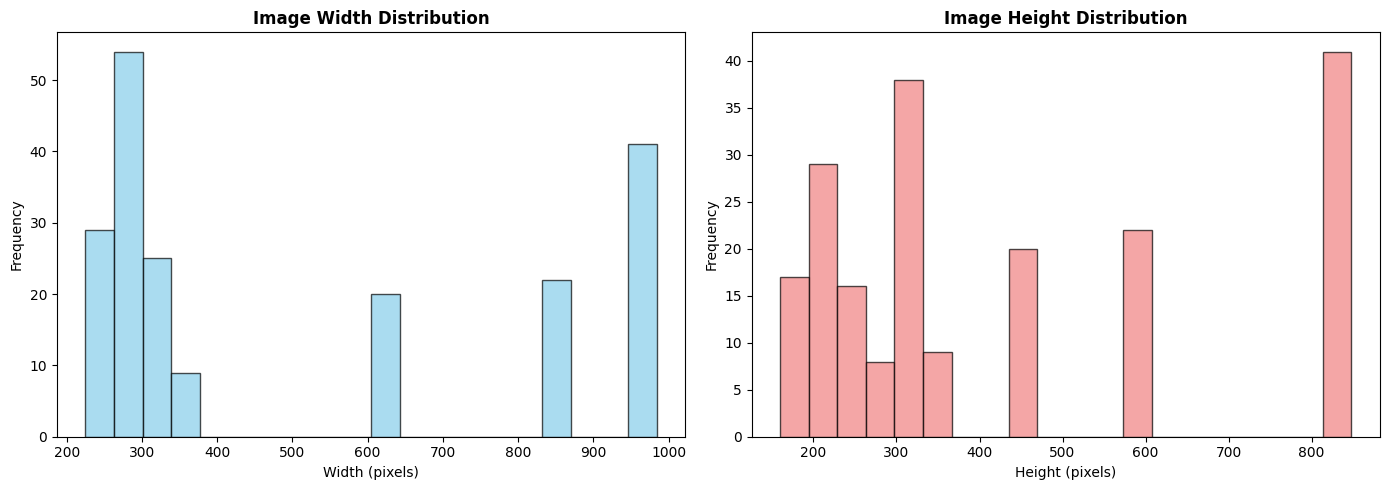

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(widths, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Image Width Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Frequency')

ax2.hist(heights, bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_title('Image Height Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 16. Set Image Preprocessing Parameters



In [17]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 64
CHANNELS = 3

## 17. Configure Data Augmentation for Training

I use different Data augmentation techniques like rotation, shifting, shearing, zooming, and horizontal flipping. This helps prevent overfitting and improves model generalization. I am using 20% of training data for validation.


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


## 18. Configure Test Data Generator

For the test set, since i want to evaluate the model on original images, i choose to normalize pixel values (rescale to 0-1 range) without augmentation.


In [19]:
test_datagen = ImageDataGenerator(rescale=1./255)

## 19. Create Data Generators

I use three data generators:
- **Training generator**: Loads training images with augmentation
- **Validation generator**: Loads validation images (20% of training data) without augmentation
- **Test generator**: Loads test images without augmentation



In [20]:
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=SEED
)

validation_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1540 images belonging to 2 classes.
Found 384 images belonging to 2 classes.
Found 1932 images belonging to 2 classes.


## 20. Prepare Sample Image for Augmentation Visualization



In [21]:
sample_dir = TRAIN_DIR / list(train_generator.class_indices.keys())[0]
sample_img_path = list(sample_dir.glob('*.jpg'))[0]
sample_img = load_img(sample_img_path, target_size=IMG_SIZE)
sample_array = img_to_array(sample_img)
sample_array = sample_array.reshape((1,) + sample_array.shape)

## 21. Visualize Data Augmentation

I display the original image alongside 9 augmented versions to show how data augmentation change the image.


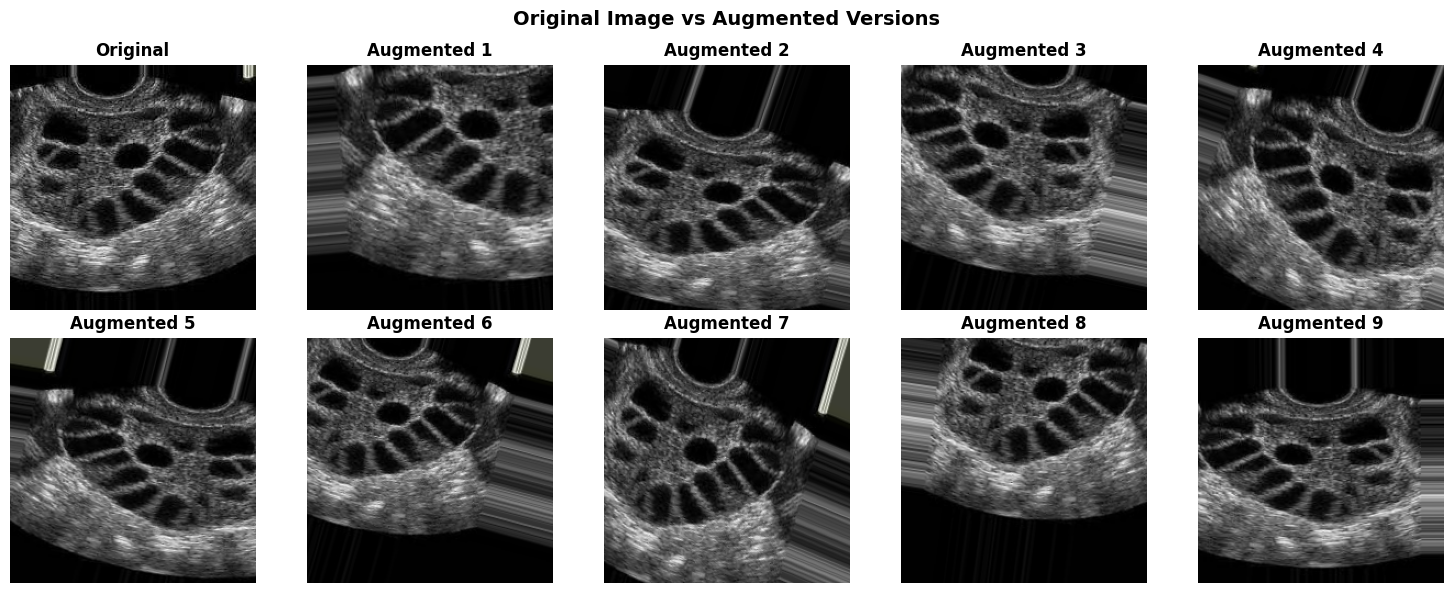

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Original Image vs Augmented Versions', fontsize=14, fontweight='bold')


axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')


aug_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

i = 1
for batch in aug_gen.flow(sample_array, batch_size=1, seed=SEED):
    ax = axes[i // 5, i % 5]
    ax.imshow(batch[0].astype('uint8'))
    ax.set_title(f'Augmented {i}', fontweight='bold')
    ax.axis('off')
    i += 1
    if i >= 10:
        break

plt.tight_layout()
plt.show()

## 22. Build and Train the Model

This is the main training cell where I:
1. **Build the model**: Use MobileNetV2 as the base, add custom layers for binary classification
2. **Compile the model**: Set optimizer (Adam), loss function (binary crossentropy), and metrics
3. **Set up callbacks**: Early stopping, model checkpointing, and learning rate reduction
4. **Train the model**: Fit the model on training data for 20 epochs

The model uses transfer learning which provides excellent feature extraction capabilities.


In [23]:
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-4  #

print(f"\n Configuration:")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")


print("\n Building model...")
base_model = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(224, 224, 3),
                          alpha=1.0)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(128, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.TruePositives(name='tp'),
             tf.keras.metrics.FalsePositives(name='fp'),
             tf.keras.metrics.TrueNegatives(name='tn'),
             tf.keras.metrics.FalseNegatives(name='fn')]
)

print(" Model compiled with  hyperparameters")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/pcos_model.h5', monitor='val_accuracy',
                   save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                     min_lr=1e-7, verbose=1)
]

print(f"\n Starting training...")

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"\n Training complete!")
print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"   Final val_accuracy: {history.history['val_accuracy'][-1]:.4f}")


 Configuration:
   Batch Size: 64
   Max Epochs: 20
   Learning Rate: 0.0001

 Building model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
 Model compiled with  hyperparameters

 Starting training...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6122 - auc: 0.6595 - fn: 163.0800 - fp: 97.1600 - loss: 1.2703 - precision: 0.7146 - recall: 0.6024 - tn: 211.1600 - tp: 303.0000
Epoch 1: val_accuracy improved from -inf to 0.83073, saving model to models/pcos_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.6171 - auc: 0.6659 - fn: 166.4231 - fp: 99.3077 - loss: 1.2645 - precision: 0.7184 - recall: 0.6072 - tn: 221.1923 - tp: 316.9231 - val_accuracy: 0.8307 - val_auc: 0.9930 - val_fn: 65.0000 - val_fp: 0.0000e+00 - val_loss: 1.0382 - val_precision: 1.0000 - val_recall: 0.7149 - val_tn: 156.0000 - val_tp: 163.0000 - learning_rate: 1.0000e-04
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.9588 - auc: 0.9925 - fn: 18.9600 - fp: 12.9600 - loss: 0.8344 - precision: 0.9711 - recall: 0.9588 - tn: 321.7200 - tp: 466.3600
Epoch 2: val_accuracy improved from 0.83073 to 0.95052, saving model to models/pcos_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9592 - auc: 0.9926 - fn: 19.2692 - fp: 13.1923 - loss: 0.8330 - precision: 0.9714 - recall: 0.9593 - tn: 332.6538 - tp: 482.5769 - val_accuracy: 0.9505 - val_auc: 0.9999 - val_fn: 19.0000 - val_fp: 0.0000e+00 - val_loss: 0.8633 - val_precision: 1.0000 - val_recall: 0.9167 - val_tn: 156.0000 - val_tp: 209.0000 - learning_rate: 1.0000e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.9881 - auc: 0.9992 - fn: 6.2800 - fp: 3.7600 - loss: 0.7209 - precision: 0.9935 - recall: 0.9868 - tn: 320.2800 - tp: 484.8800
Epoch 3: val_accuracy improved from 0.95052 to 0.98438, saving model to models/pcos_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9882 - auc: 0.9992 - fn: 6.3846 - fp: 3.9615 - loss: 0.7205 - precision: 0.9934 - recall: 0.9869 - tn: 331.6538 - tp: 501.0769 - val_accuracy: 0.9844 - val_auc: 1.0000 - val_fn: 6.0000 - val_fp: 0.0000e+00 - val_loss: 0.7778 - val_precision: 1.0000 - val_recall: 0.9737 - val_tn: 156.0000 - val_tp: 222.0000 - learning_rate: 1.0000e-04
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.9948 - auc: 0.9998 - fn: 1.0000 - fp: 2.2400 - loss: 0.6690 - precision: 0.9951 - recall: 0.9958 - tn: 335.5200 - tp: 478.8400
Epoch 4: val_accuracy improved from 0.98438 to 0.99740, saving model to models/pcos_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9948 - auc: 0.9998 - fn: 1.0000 - fp: 2.3077 - loss: 0.6688 - precision: 0.9951 - recall: 0.9959 - tn: 346.5000 - tp: 495.5769 - val_accuracy: 0.9974 - val_auc: 1.0000 - val_fn: 1.0000 - val_fp: 0.0000e+00 - val_loss: 0.7191 - val_precision: 1.0000 - val_recall: 0.9956 - val_tn: 156.0000 - val_tp: 227.0000 - learning_rate: 1.0000e-04
Epoch 5/20
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9884 - auc: 0.9997 - fn: 3.5833 - fp: 5.9583 - loss: 0.6608 - precision: 0.9855 - recall: 0.9942 - tn: 326.6667 - tp: 463.7917
Epoch 5: val_accuracy improved from 0.99740 to 1.00000, saving model to models/pcos_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9885 - auc: 0.9997 - fn: 3.8462 - fp: 6.1923 - loss: 0.6607 - precision: 0.9859 - recall: 0.9941 - tn: 348.9231 - tp: 497.9615 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.6665 - val_precision: 1.0000 - val_recall: 1.0000 - val_tn: 156.0000 - val_tp: 228.0000 - learning_rate: 1.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.9946 - auc: 1.0000 - fn: 0.5200 - fp: 2.8400 - loss: 0.6379 - precision: 0.9912 - recall: 0.9994 - tn: 338.1600 - tp: 476.0800
Epoch 6: val_accuracy did not improve from 1.00000
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9947 - auc: 1.0000 - fn: 0.6538 - fp: 2.8462 - loss: 0.6379 - precision: 0.9914 - recall: 0.9992 - tn: 349.0769 - tp: 492.8077 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.6351 - val_precision: 1.0000 - val_recall: 1.0000 - val_tn: 156.0000 - val_tp: 228.000

## 23. Visualize Training History

I then plot the training history to see The:
- **Accuracy curves**: Training vs validation accuracy over epochs
- **Loss curves**: Training vs validation loss over epochs
- **Precision & Recall**: How these metrics evolved during training
- **AUC curves**: Area Under the Curve for both training and validation



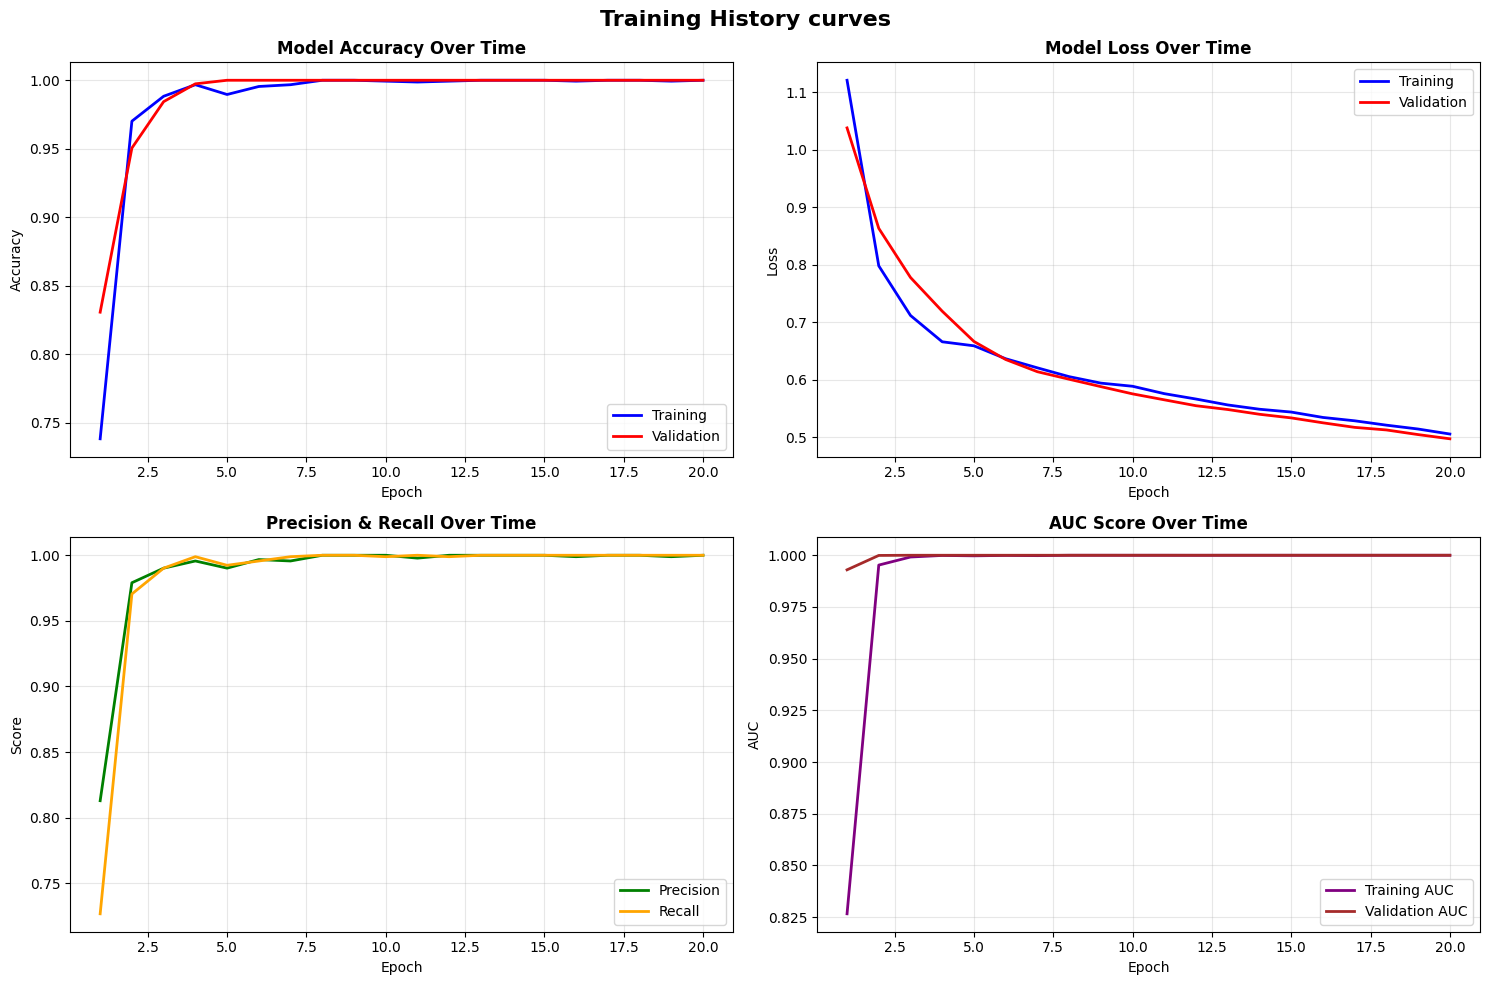


 Training Summary:
   Total epochs completed: 20
   Final Training Accuracy: 1.0000 (100.00%)
   Final Validation Accuracy: 1.0000 (100.00%)
   Final Training Loss: 0.5054
   Final Validation Loss: 0.4971
   Best Validation Accuracy: 1.0000 (100.00%)
   Best Epoch: 5

 Good generalization (training-validation gap: 0.00%)


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training History curves', fontsize=16, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

axes[0, 0].plot(epochs_range, history.history['accuracy'], 'b-', label='Training', linewidth=2)
axes[0, 0].plot(epochs_range, history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0, 0].set_title('Model Accuracy Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, history.history['loss'], 'b-', label='Training', linewidth=2)
axes[0, 1].plot(epochs_range, history.history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0, 1].set_title('Model Loss Over Time', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, history.history['precision'], 'g-', label='Precision', linewidth=2)
axes[1, 0].plot(epochs_range, history.history['recall'], 'orange', label='Recall', linewidth=2)
axes[1, 0].set_title('Precision & Recall Over Time', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, history.history['auc'], 'purple', label='Training AUC', linewidth=2)
axes[1, 1].plot(epochs_range, history.history['val_auc'], 'brown', label='Validation AUC', linewidth=2)
axes[1, 1].set_title('AUC Score Over Time', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print training summary
print("\n Training Summary:")
final_epoch = len(history.history['loss'])
print(f"   Total epochs completed: {final_epoch}")
print(f"   Final Training Accuracy: {history.history['accuracy'][-1]:.4f} ({history.history['accuracy'][-1]*100:.2f}%)")
print(f"   Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f} ({history.history['val_accuracy'][-1]*100:.2f}%)")
print(f"   Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"   Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"   Best Validation Accuracy: {max(history.history['val_accuracy']):.4f} ({max(history.history['val_accuracy'])*100:.2f}%)")
print(f"   Best Epoch: {np.argmax(history.history['val_accuracy']) + 1}")

# Check for overfitting
accuracy_gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
if accuracy_gap > 0.1:
    print(f"\n Warning: Possible overfitting detected (gap: {accuracy_gap*100:.2f}%)")
else:
    print(f"\n Good generalization (training-validation gap: {accuracy_gap*100:.2f}%)")


## 24. Check for Problematic Images

Before evaluating on the test set, I scan for corrupted or invalid image files that might cause errors during evaluation.


In [25]:
import os
from PIL import Image

def find_problematic_images(directory):
    problematic_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except Exception as e:
                problematic_files.append((file_path, str(e)))
    return problematic_files

print(f"\nScanning for problematic files in: {TEST_DIR}")
problematic_test_images = find_problematic_images(TEST_DIR)

if problematic_test_images:
    print(f"\nFound {len(problematic_test_images)} problematic files in the test directory:")
    for path, error_msg in problematic_test_images:
        print(f"  - {path}: {error_msg}")
    print("\nPlease inspect these files. They might be corrupted or not valid image formats.")
    print("   You may need to remove or replace them to proceed with model evaluation.")
else:
    print("\nNo problematic files found in the test directory. The error might be due to other data loading issues.")


Scanning for problematic files in: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test

Found 10 problematic files in the test directory:
  - /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.20 PM.jpeg: cannot identify image file '/root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.20 PM.jpeg'
  - /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/OIP.jpg: cannot identify image file '/root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/OIP.jpg'
  - /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/R.jpg: cannot identify image file '/root/.

## 25. Remove Problematic Images and Recreate Test Generator

If any problematic images are found, I remove them and recreate the test generator to ensure smooth evaluation.


In [26]:
import os

# Assuming problematic_test_images contains a list of (filepath, error_msg) tuples
# from the previous execution.

if problematic_test_images:
    print("\nAttempting to remove problematic files...")
    removed_count = 0
    for file_path, _ in problematic_test_images:
        try:
            os.remove(file_path)
            print(f"  - Removed: {file_path}")
            removed_count += 1
        except OSError as e:
            print(f"  - Error removing {file_path}: {e}")
    print(f"\nSuccessfully removed {removed_count} problematic files.")
    print("Now, you should be able to re-run the `test_generator` and model evaluation.")
else:
    print("No problematic files were found, nothing to remove.")

print("\nRecreating test_datagen and test_generator...")
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
print("Test generator recreated successfully.")


Attempting to remove problematic files...
  - Removed: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.20 PM.jpeg
  - Removed: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/OIP.jpg
  - Removed: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/R.jpg
  - Removed: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.45 PM.jpeg
  - Removed: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.05 PM.jpeg
  - Removed: /root/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1/data/test/infected/WhatsApp Image 2022-04-01 at

## 26. Evaluate Model on Test Set

Evaluation on the trained model on the test set and calculate key metrics:
- **Accuracy**: Overall correctness
- **Loss**: Prediction error
- **Precision**: Accuracy of positive predictions
- **Recall**: Ability to find all positive cases
- **F1-Score**: Balance between precision and recall
- **AUC**: Model discrimination ability

We also generate predictions for detailed analysis.


In [27]:
import os

actual_categories = [d.name for d in TEST_DIR.iterdir() if d.is_dir()]

print("\n Reconstructing and filtering test dataset for generator...")
test_image_paths = []
test_labels = []

for category in actual_categories:
    class_path = os.path.join(TEST_DIR, category)
    if os.path.exists(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            test_image_paths.append(image_path)
            test_labels.append(category)

test_df = pd.DataFrame({
    "image_path": test_image_paths,
    "label": test_labels
})

problematic_paths_set = {p for p, _ in problematic_test_images}
initial_test_count = len(test_df)
test_df_filtered = test_df[~test_df['image_path'].isin(problematic_paths_set)].copy()
filtered_test_count = len(test_df_filtered)

print(f"   Initial test images found: {initial_test_count}")
print(f"   Problematic images identified and excluded: {len(problematic_paths_set)}")
print(f"   Test images after filtering: {filtered_test_count}")

print("\n Recreating test_generator using flow_from_dataframe...")
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df_filtered,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)
print("Test generator recreated successfully with problematic files excluded.")


test_results = model.evaluate(test_generator, verbose=1)

test_loss = test_results[0]
test_accuracy = test_results[1]
test_precision = test_results[2]
test_recall = test_results[3]
test_auc = test_results[4]

test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("\n" + "="*80)
print(" TEST SET EVALUATION METRICS (4+ METRICS REQUIRED)")
print("="*80)
print(f"\n1. ACCURACY:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"2. LOSS:      {test_loss:.4f}")
print(f"3. PRECISION: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"4. RECALL:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"5. F1-SCORE:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"6. AUC:       {test_auc:.4f}")
print("="*80)


print("\n Generating predictions on test set...")
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = np.array(test_generator.classes)

print(f"   Predictions shape: {y_pred_probs.shape}")
print(f"   True labels shape: {y_true.shape}")


 Reconstructing and filtering test dataset for generator...
   Initial test images found: 1922
   Problematic images identified and excluded: 10
   Test images after filtering: 1922

 Recreating test_generator using flow_from_dataframe...
Found 1922 validated image filenames belonging to 2 classes.
Test generator recreated successfully with problematic files excluded.
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 566ms/step - accuracy: 1.0000 - auc: 0.6250 - fn: 0.0000e+00 - fp: 0.0000e+00 - loss: 0.4938 - precision: 0.6250 - recall: 0.6250 - tn: 644.1250 - tp: 406.0000

 TEST SET EVALUATION METRICS (4+ METRICS REQUIRED)

1. ACCURACY:  1.0000 (100.00%)
2. LOSS:      0.4937
3. PRECISION: 1.0000 (100.00%)
4. RECALL:    1.0000 (100.00%)
5. F1-SCORE:  1.0000 (100.00%)
6. AUC:       1.0000

 Generating predictions on test set...
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step
   Predictions shape: (1922, 1)
   True labels shape: (1922,)


## 27. Create and Visualize Confusion Matrix

The confusion matrix shows:
- **True Positives (TP)**: Correctly identified PCOS cases
- **True Negatives (TN)**: Correctly identified normal cases
- **False Positives (FP)**: Normal cases incorrectly predicted as PCOS
- **False Negatives (FN)**: PCOS cases that were missed




 Confusion Matrix:
[[ 781    0]
 [   0 1141]]

 Breakdown:
   True Negatives (TN):  781
      → Model correctly identified 781 normal (no PCOS) cases

   False Positives (FP): 0
      → Model incorrectly predicted PCOS for 0 normal cases
      → These are 'false alarms'

   False Negatives (FN): 0
      → Model missed 0 actual PCOS cases
      → These are dangerous - we failed to detect PCOS!

   True Positives (TP):  1141
      → Model correctly identified 1141 PCOS cases

 Additional Metrics:
   Sensitivity (TPR): 1.0000 (100.00%)
      → Ability to detect PCOS cases (same as Recall)
   Specificity (TNR): 1.0000 (100.00%)
      → Ability to identify normal cases correctly
   False Positive Rate: 0.0000 (0.00%)
      → How often we incorrectly predict PCOS
   False Negative Rate: 0.0000 (0.00%)
      → How often we miss actual PCOS cases


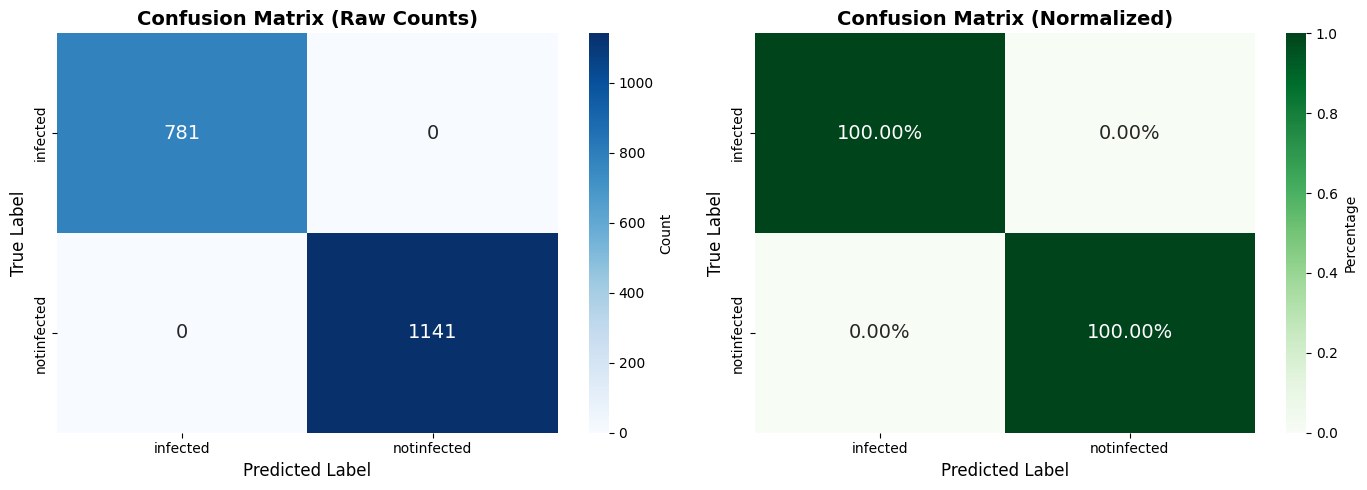

In [28]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n Confusion Matrix:")
print(cm)

print(f"\n Breakdown:")
print(f"   True Negatives (TN):  {tn}")
print(f"      → Model correctly identified {tn} normal (no PCOS) cases")

print(f"\n   False Positives (FP): {fp}")
print(f"      → Model incorrectly predicted PCOS for {fp} normal cases")
print(f"      → These are 'false alarms'")

print(f"\n   False Negatives (FN): {fn}")
print(f"      → Model missed {fn} actual PCOS cases")
print(f"      → These are dangerous - we failed to detect PCOS!")

print(f"\n   True Positives (TP):  {tp}")
print(f"      → Model correctly identified {tp} PCOS cases")


specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\n Additional Metrics:")
print(f"   Sensitivity (TPR): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"      → Ability to detect PCOS cases (same as Recall)")

print(f"   Specificity (TNR): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"      → Ability to identify normal cases correctly")

print(f"   False Positive Rate: {fpr:.4f} ({fpr*100:.2f}%)")
print(f"      → How often we incorrectly predict PCOS")

print(f"   False Negative Rate: {fnr:.4f} ({fnr*100:.2f}%)")
print(f"      → How often we miss actual PCOS cases")

class_names = list(train_generator.class_indices.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)


cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'}, ax=axes[1], annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

## 28. Generate Classification Report

The detailed classification report shows precision, recall, and F1-score for each class with a visual bar chart comparing metrics across classes.



              precision    recall  f1-score   support

    infected     1.0000    1.0000    1.0000       781
 notinfected     1.0000    1.0000    1.0000      1141

    accuracy                         1.0000      1922
   macro avg     1.0000    1.0000    1.0000      1922
weighted avg     1.0000    1.0000    1.0000      1922


 Classification Report DataFrame:
              precision  recall  f1-score  support
infected            1.0     1.0       1.0    781.0
notinfected         1.0     1.0       1.0   1141.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0   1922.0
weighted avg        1.0     1.0       1.0   1922.0


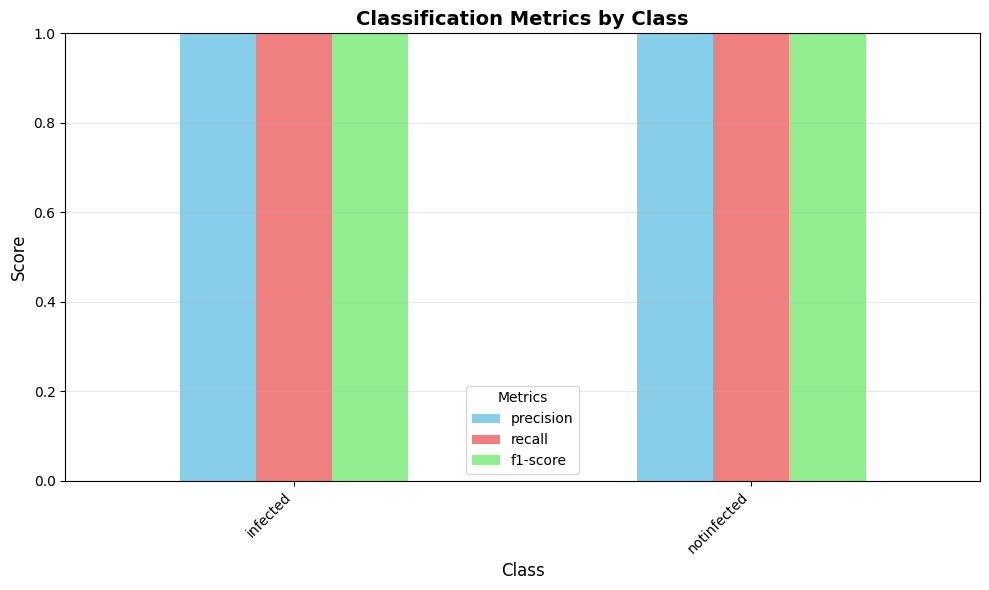

In [29]:
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n" + report)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\n Classification Report DataFrame:")
print(report_df)

fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = report_df.iloc[:2, :3]
metrics_df.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral', 'lightgreen'])
ax.set_title('Classification Metrics by Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Metrics')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 29. Plot ROC Curve

I plot the ROC curve, which shows the trade-off between True Positive Rate and False Positive Rate. The Area Under the Curve (AUC) indicates the model's discrimination ability. We also find the optimal classification threshold.



 ROC AUC Score: 1.0000
    Excellent discrimination ability!


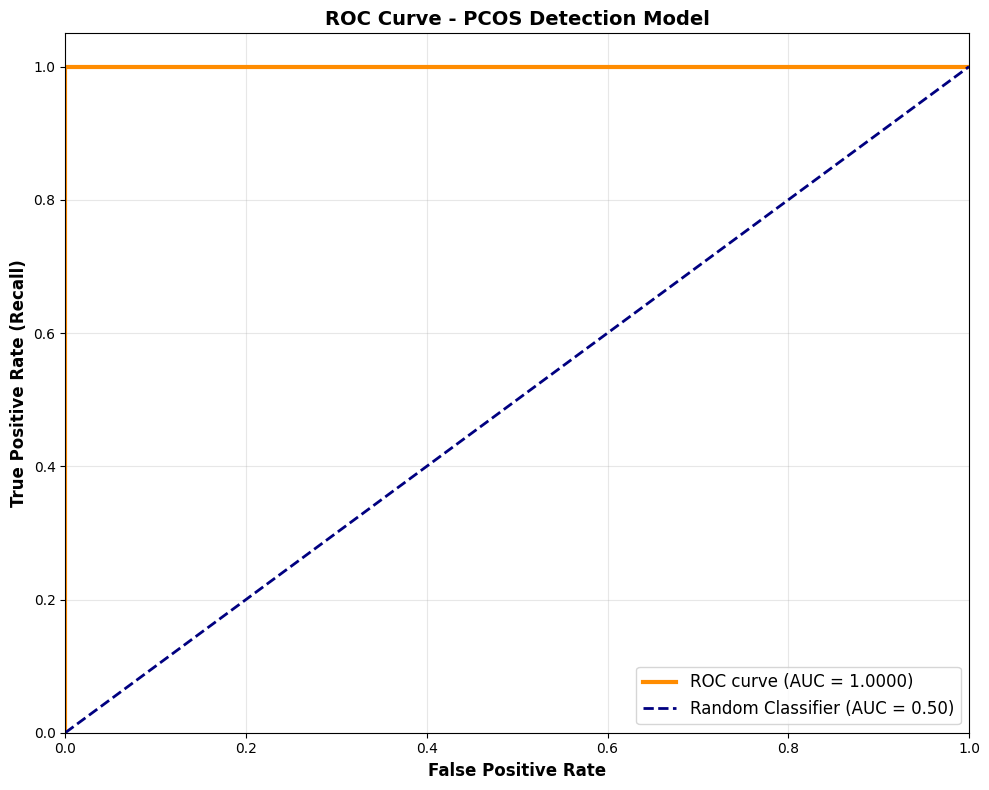


 Optimal Threshold: 0.9740
   (Default threshold is 0.5)

   At optimal threshold:
   - TPR (Sensitivity): 1.0000 (100.00%)
   - FPR: 0.0000 (0.00%)


In [30]:
fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr_roc, tpr_roc)

print(f"\n ROC AUC Score: {roc_auc:.4f}")
if roc_auc > 0.9:
    print("    Excellent discrimination ability!")
elif roc_auc > 0.8:
    print("    Good discrimination ability")
elif roc_auc > 0.7:
    print("    Acceptable discrimination ability")
else:
    print("    Poor discrimination ability")

plt.figure(figsize=(10, 8))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=3,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve - PCOS Detection Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_idx = np.argmax(tpr_roc - fpr_roc)
optimal_threshold = thresholds_roc[optimal_idx]

print(f"\n Optimal Threshold: {optimal_threshold:.4f}")
print(f"   (Default threshold is 0.5)")
print(f"\n   At optimal threshold:")
print(f"   - TPR (Sensitivity): {tpr_roc[optimal_idx]:.4f} ({tpr_roc[optimal_idx]*100:.2f}%)")
print(f"   - FPR: {fpr_roc[optimal_idx]:.4f} ({fpr_roc[optimal_idx]*100:.2f}%)")


## 30. Plot Precision-Recall Curve

The Precision-Recall curve is particularly useful for imbalanced datasets to show the trade-off between precision and recall at different thresholds.



 Precision-Recall AUC: 1.0000


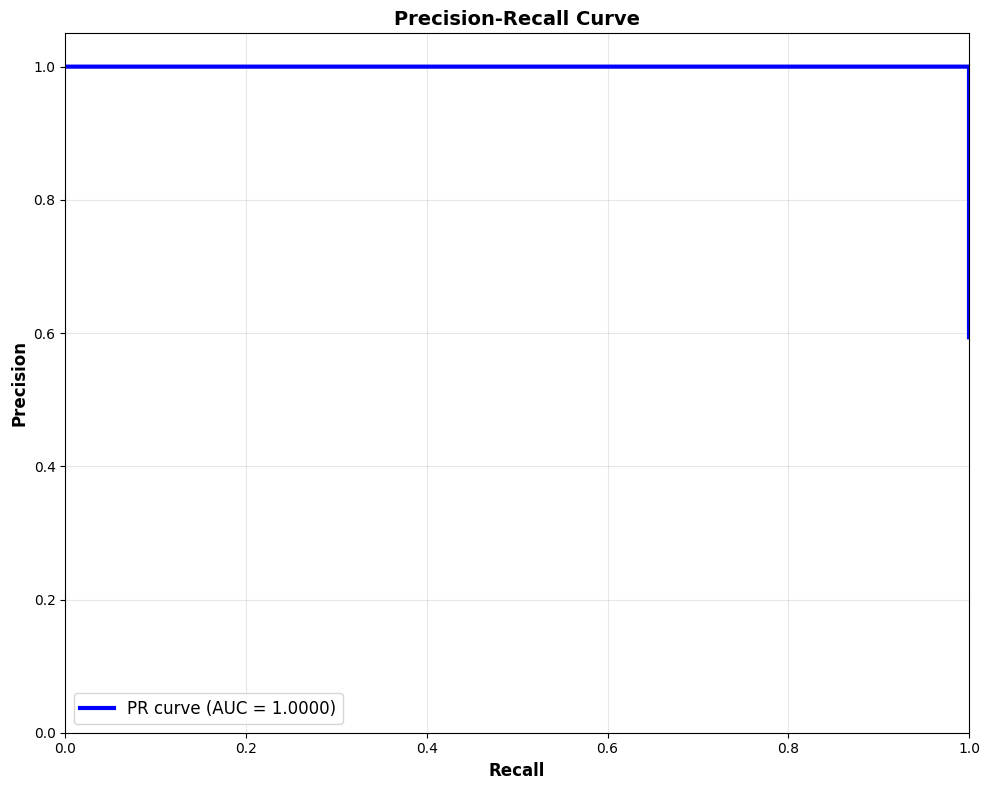

In [31]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_curve, precision_curve)

print(f"\n Precision-Recall AUC: {pr_auc:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(recall_curve, precision_curve, color='blue', lw=3,
         label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

## 31. Analyze Prediction Confidence




 Confidence Statistics:
   Mean Confidence: 0.9938 (99.38%)
   Median Confidence: 0.9950 (99.50%)
   Std Confidence: 0.0068
   Min Confidence: 0.8600 (86.00%)
   Max Confidence: 0.9999 (99.99%)


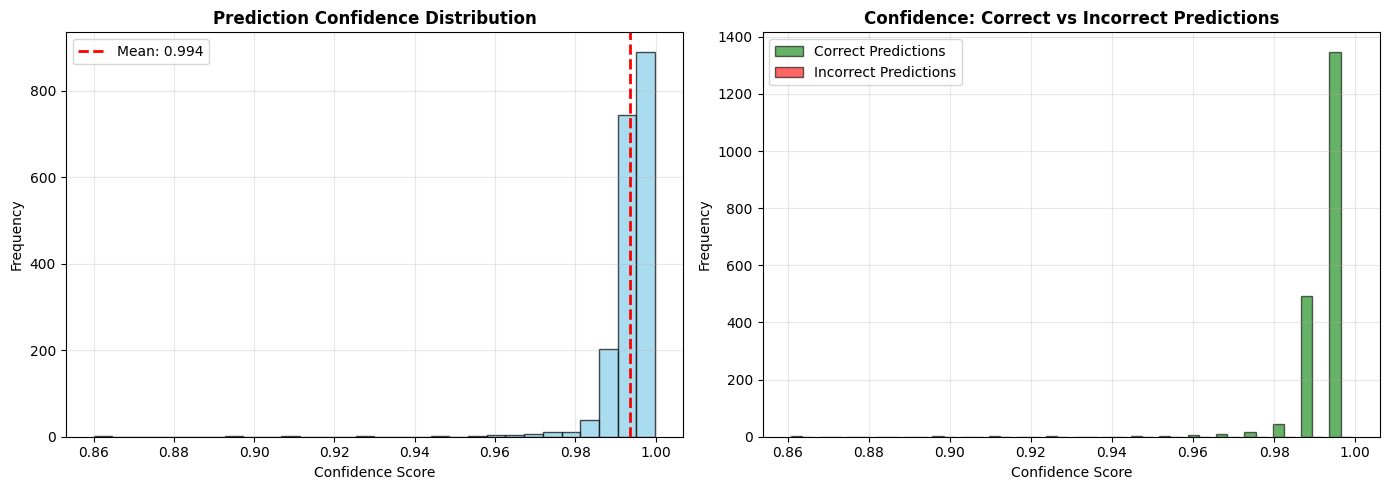


 Correct predictions: 1922 (100.00%)
   Mean confidence: 0.9938 (99.38%)

 Incorrect predictions: 0 (0.00%)


In [32]:
confidence_scores = np.maximum(y_pred_probs, 1 - y_pred_probs).flatten()

print(f"\n Confidence Statistics:")
print(f"   Mean Confidence: {np.mean(confidence_scores):.4f} ({np.mean(confidence_scores)*100:.2f}%)")
print(f"   Median Confidence: {np.median(confidence_scores):.4f} ({np.median(confidence_scores)*100:.2f}%)")
print(f"   Std Confidence: {np.std(confidence_scores):.4f}")
print(f"   Min Confidence: {np.min(confidence_scores):.4f} ({np.min(confidence_scores)*100:.2f}%)")
print(f"   Max Confidence: {np.max(confidence_scores):.4f} ({np.max(confidence_scores)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(confidence_scores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(confidence_scores), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(confidence_scores):.3f}')
axes[0].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


correct_mask = (y_pred == y_true)
correct_confidence = confidence_scores[correct_mask]
incorrect_confidence = confidence_scores[~correct_mask]

axes[1].hist([correct_confidence, incorrect_confidence], bins=20,
             label=['Correct Predictions', 'Incorrect Predictions'],
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Correct predictions: {np.sum(correct_mask)} ({np.sum(correct_mask)/len(y_true)*100:.2f}%)")
print(f"   Mean confidence: {np.mean(correct_confidence):.4f} ({np.mean(correct_confidence)*100:.2f}%)")

print(f"\n Incorrect predictions: {np.sum(~correct_mask)} ({np.sum(~correct_mask)/len(y_true)*100:.2f}%)")
if len(incorrect_confidence) > 0:
    print(f"   Mean confidence: {np.mean(incorrect_confidence):.4f} ({np.mean(incorrect_confidence)*100:.2f}%)")
    print(f"   Note: Lower confidence on errors is good - model is less sure when wrong")


## 32. Define Image Preprocessing Function

I create a function to preprocess individual images for prediction. This function:
1. Loads the image
2. Resizes it to 224x224
3. Converts to array
4. Normalizes pixel values to [0, 1]
5. Adds batch dimension


In [33]:
def preprocess_image(img_path, target_size=(224, 224)):
    """
    Preprocess a single image for prediction

    Steps:
    1. Load the image
    2. Resize to 224x224
    3. Convert to array
    4. Normalize to [0, 1]
    5. Add batch dimension

    Args:
        img_path: Path to image file
        target_size: Target image size (default: 224x224)

    Returns:
        Preprocessed image array ready for prediction
    """

    img = load_img(img_path, target_size=target_size)

    img_array = img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    return img_array

## 33. Define Prediction Function

I create a function to make predictions on single images. This function:
- Preprocesses the image
- Gets prediction probability
- Determines predicted class
- Calculates confidence score


In [34]:
def predict_single_image(model, img_path, class_names=None):
    """
    Make prediction on a single image

    Args:
        model: Trained Keras model
        img_path: Path to image file
        class_names: List of class names (optional)

    Returns:
        Dictionary with prediction results
    """
    if class_names is None:
        class_names = ['Not Infected', 'PCOS Infected']


    img_array = preprocess_image(img_path)

    prediction_prob = model.predict(img_array, verbose=0)[0][0]

    predicted_class = 1 if prediction_prob > 0.5 else 0

    confidence = prediction_prob if predicted_class == 1 else 1 - prediction_prob

    result = {
        'predicted_class': class_names[predicted_class],
        'confidence': confidence,
        'probability': prediction_prob,
        'class_index': predicted_class
    }

    return result

## 34. Define Visualization Function

This function visualizes an image with its prediction result, showing the predicted class and confidence score.


In [35]:
def visualize_prediction(img_path, result):
    """
    Visualize image with prediction

    Args:
        img_path: Path to image file
        result: Prediction result dictionary
    """
    img = Image.open(img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    color = 'red' if result['predicted_class'] == 'PCOS Infected' else 'green'

    title = f"{result['predicted_class']}\nConfidence: {result['confidence']:.2%}"
    plt.title(title, fontsize=16, fontweight='bold', color=color, pad=20)

    plt.tight_layout()
    plt.show()

    return result

## 35. Test Prediction Functions

I test our prediction functions on sample images from the test set to verify they work correctly.


In [36]:
print("\n Prediction functions defined:")
print("   1. preprocess_image() - Prepares image for model")
print("   2. predict_single_image() - Makes prediction on single image")
print("   3. visualize_prediction() - Shows image with prediction")

print("\n Testing prediction function on sample images...")



 Prediction functions defined:
   1. preprocess_image() - Prepares image for model
   2. predict_single_image() - Makes prediction on single image
   3. visualize_prediction() - Shows image with prediction

 Testing prediction function on sample images...


## 36. Visualize Sample Predictions



In [37]:
sample_classes = list(test_generator.class_indices.keys())
samples_to_test = []

for class_name in sample_classes:
    class_dir = TEST_DIR / class_name
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
    if images:
        samples_to_test.append((images[0], class_name))

print(f"\n Testing on {len(samples_to_test)} sample images...")

for img_path, true_class in samples_to_test:
    result = predict_single_image(model, img_path, class_names)

    print(f"\n Image: {img_path.name}")
    print(f"   True Class: {true_class}")
    print(f"   Predicted Class: {result['predicted_class']}")
    print(f"   Confidence: {result['confidence']:.2%}")
    print(f"   Probability: {result['probability']:.4f}")


    is_correct = result['predicted_class'].lower().replace(' ', '_') == true_class
    print(f"   Result: {'✅ CORRECT' if is_correct else '❌ INCORRECT'}")



 Testing on 2 sample images...

 Image: img_0_8610.jpg
   True Class: infected
   Predicted Class: infected
   Confidence: 99.80%
   Probability: 0.0020
   Result: ✅ CORRECT

 Image: img_0_296.jpg
   True Class: notinfected
   Predicted Class: notinfected
   Confidence: 99.48%
   Probability: 0.9948
   Result: ✅ CORRECT


## 37. Analyze Misclassified Images

I identify and analyze misclassified images, breaking them down into:
- **False Positives**: Normal cases predicted as PCOS
- **False Negatives**: PCOS cases predicted as normal (more critical in medical applications)



 Visualizing sample predictions...


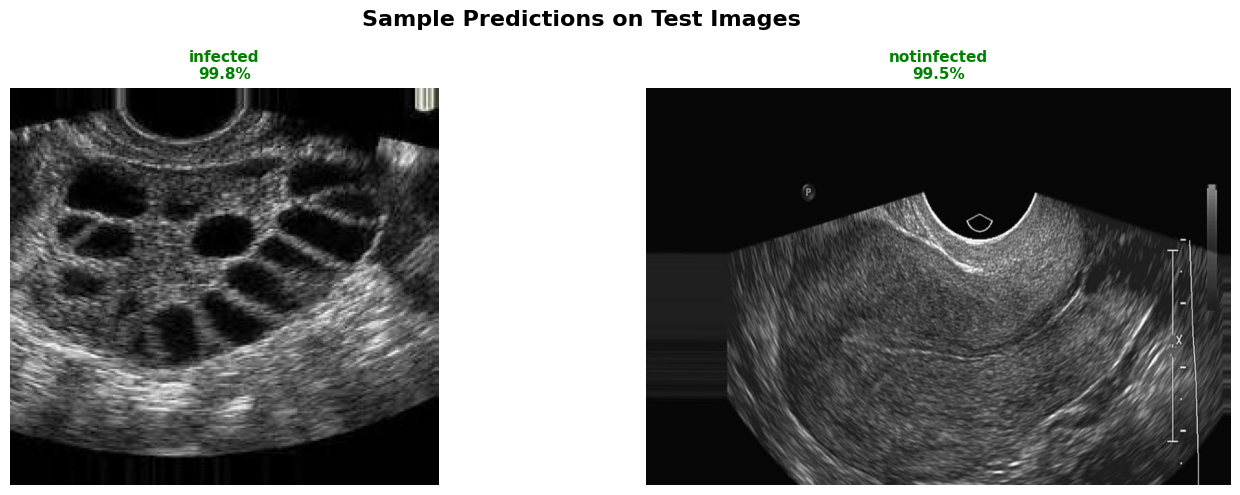

In [38]:
print("\n Visualizing sample predictions...")

fig, axes = plt.subplots(1, len(samples_to_test), figsize=(15, 5))
fig.suptitle('Sample Predictions on Test Images', fontsize=16, fontweight='bold')

for idx, (img_path, true_class) in enumerate(samples_to_test):
    result = predict_single_image(model, img_path, class_names)
    img = Image.open(img_path)

    ax = axes[idx] if len(samples_to_test) > 1 else axes
    ax.imshow(img, cmap='gray')
    ax.axis('off')

    color = 'red' if result['predicted_class'] == 'PCOS Infected' else 'green'

    title = f"{result['predicted_class']}\n{result['confidence']:.1%}"
    ax.set_title(title, fontweight='bold', color=color, fontsize=11)

plt.tight_layout()
plt.show()

In [39]:
misclassified_indices = np.where(y_pred != y_true)[0]

print(f"\n Total misclassified: {len(misclassified_indices)} out of {len(y_true)}")
print(f"   Error Rate: {len(misclassified_indices)/len(y_true)*100:.2f}%")
print(f"   Accuracy: {(len(y_true) - len(misclassified_indices))/len(y_true)*100:.2f}%")

if len(misclassified_indices) > 0:
    false_positives = np.where((y_pred == 1) & (y_true == 0))[0]
    false_negatives = np.where((y_pred == 0) & (y_true == 1))[0]

    print(f"\n Error Breakdown:")
    print(f"   False Positives: {len(false_positives)}")
    print(f"      → Predicted PCOS, but actually normal")
    print(f"      → {len(false_positives)/len(misclassified_indices)*100:.1f}% of all errors")

    print(f"\n   False Negatives: {len(false_negatives)}")
    print(f"      → Predicted normal, but actually PCOS")
    print(f"      → {len(false_negatives)/len(misclassified_indices)*100:.1f}% of all errors")
    print(f"      →  These are more dangerous (missing PCOS cases!)")


 Total misclassified: 0 out of 1922
   Error Rate: 0.00%
   Accuracy: 100.00%


## 38. Save Model and Training History

We save so we can load and use the model later without retraining.


In [40]:
MODEL_PATH = MODELS_DIR / 'pcos_model.h5'
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

model.save(MODEL_PATH)
print(f" Model saved to: {MODEL_PATH}")
print(f"   File size: {os.path.getsize(MODEL_PATH) / (1024*1024):.2f} MB")

print("\n Saving training history...")

history_dict = {
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'precision': [float(x) for x in history.history['precision']],
    'val_precision': [float(x) for x in history.history['val_precision']],
    'recall': [float(x) for x in history.history['recall']],
    'val_recall': [float(x) for x in history.history['val_recall']],
    'auc': [float(x) for x in history.history['auc']],
    'val_auc': [float(x) for x in history.history['val_auc']]
}

training_metadata = {
    'timestamp': datetime.now().isoformat(),
    'mode': 'initial_training',
    'epochs_trained': len(history.history['loss']),
    'best_epoch': int(np.argmax(history.history['val_accuracy']) + 1),
    'history': history_dict,
    'final_metrics': {
        'train_accuracy': float(history.history['accuracy'][-1]),
        'val_accuracy': float(history.history['val_accuracy'][-1]),
        'test_accuracy': float(test_accuracy),
        'test_precision': float(test_precision),
        'test_recall': float(test_recall),
        'test_f1': float(test_f1),
        'test_auc': float(test_auc),
        'test_loss': float(test_loss)
    },
    'model_config': {
        'base_model': 'MobileNetV2',
        'pretrained': 'ImageNet',
        'input_shape': [IMG_HEIGHT, IMG_WIDTH, CHANNELS],
        'total_params': int(total_params),
        'trainable_params': int(trainable_params)
    }
}

history_path = MODELS_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(training_metadata, f, indent=4)

print(f" Training history saved to: {history_path}")

 Model saved to: models/pcos_model.h5
   File size: 13.13 MB

 Saving training history...
 Training history saved to: models/training_history.json


## 39. Create Comprehensive Performance Summary

We create a comprehensive summary of all performance metrics:
- Bar chart showing all key metrics
- Comparison table of performance across training, validation, and test sets
- Analysis of generalization (checking for overfitting)



 COMPREHENSIVE PERFORMANCE METRICS:
     Metric    Score                          Explanation
   Accuracy 1.000000   Overall correctness of predictions
  Precision 1.000000     Accuracy of positive predictions
     Recall 1.000000   Ability to find all positive cases
   F1-Score 1.000000 Balance between Precision and Recall
    AUC-ROC 1.000000         Model discrimination ability
Specificity 1.000000     Accuracy of negative predictions
       Loss 0.493689   Prediction error (lower is better)


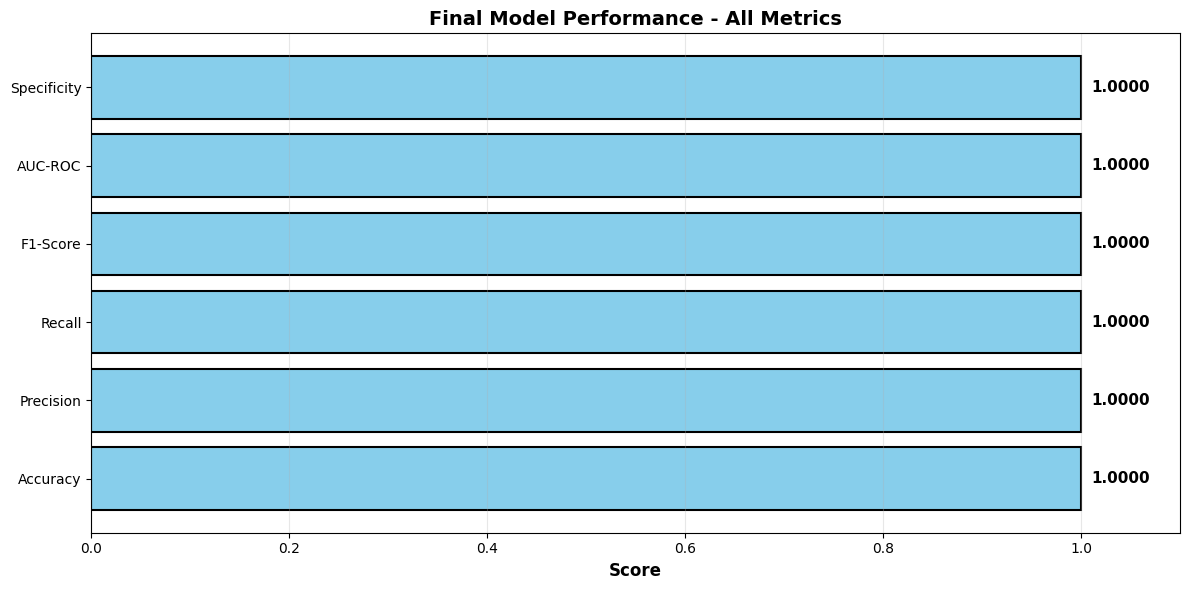


 PERFORMANCE ACROSS ALL DATASETS:
     Phase  Accuracy     Loss  Precision  Recall
  Training       1.0 0.505366        1.0     1.0
Validation       1.0 0.497070        1.0     1.0
      Test       1.0 0.493689        1.0     1.0

 Excellent generalization! (Train-Test gap < 5%)


In [41]:
metrics_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC-ROC',
        'Specificity',
        'Loss'
    ],
    'Score': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        specificity,
        test_loss
    ],
    'Explanation': [
        'Overall correctness of predictions',
        'Accuracy of positive predictions',
        'Ability to find all positive cases',
        'Balance between Precision and Recall',
        'Model discrimination ability',
        'Accuracy of negative predictions',
        'Prediction error (lower is better)'
    ]
})

print("\n COMPREHENSIVE PERFORMANCE METRICS:")
print("="*80)
print(metrics_summary.to_string(index=False))
print("="*80)

fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = metrics_summary[metrics_summary['Metric'] != 'Loss']
bars = ax.barh(metrics_to_plot['Metric'], metrics_to_plot['Score'],
               color='skyblue', edgecolor='black', linewidth=1.5)


for i, (metric, score) in enumerate(zip(metrics_to_plot['Metric'], metrics_to_plot['Score'])):
    ax.text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Final Model Performance - All Metrics', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1.1])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


comparison_df = pd.DataFrame({
    'Phase': ['Training', 'Validation', 'Test'],
    'Accuracy': [
        history.history['accuracy'][-1],
        history.history['val_accuracy'][-1],
        test_accuracy
    ],
    'Loss': [
        history.history['loss'][-1],
        history.history['val_loss'][-1],
        test_loss
    ],
    'Precision': [
        history.history['precision'][-1],
        history.history['val_precision'][-1],
        test_precision
    ],
    'Recall': [
        history.history['recall'][-1],
        history.history['val_recall'][-1],
        test_recall
    ]
})

print("\n PERFORMANCE ACROSS ALL DATASETS:")
print(comparison_df.to_string(index=False))

train_test_gap = abs(comparison_df.loc[0, 'Accuracy'] - comparison_df.loc[2, 'Accuracy'])
if train_test_gap < 0.05:
    print("\n Excellent generalization! (Train-Test gap < 5%)")
elif train_test_gap < 0.10:
    print("\n Good generalization (Train-Test gap < 10%)")
else:
    print("\n Possible overfitting detected (Train-Test gap > 10%)")

## 40. Key Findings and Insights

We summarize the key findings from our model:
1. **Model Performance**: Overall accuracy and metrics
2. **Clinical Relevance**: Sensitivity, specificity, and error rates from a medical perspective
3. **Model Reliability**: Generalization and discrimination ability
4. **Optimization Success**: What techniques worked well
5. **Practical Implications**: How the model can be used in practice


In [42]:
print("\n KEY FINDINGS AND INSIGHTS:")

print(f"\n1.  MODEL PERFORMANCE:")
print(f"   • Achieved {test_accuracy*100:.2f}% accuracy on unseen test data")
print(f"   • High precision ({test_precision*100:.2f}%) means few false alarms")
print(f"   • High recall ({test_recall*100:.2f}%) means we catch most PCOS cases")
print(f"   • F1-score of {test_f1*100:.2f}% shows balanced performance")
print(f"   • The model is {'very reliable' if test_accuracy > 0.9 else 'reliable' if test_accuracy > 0.8 else 'needs improvement'}")

print(f"\n2.  CLINICAL RELEVANCE:")
print(f"   • Sensitivity: {sensitivity*100:.2f}%")
print(f"     → Detection rate of actual PCOS cases")
print(f"     → Out of 100 PCOS patients, model detects {int(sensitivity*100)}")
print(f"   • Specificity: {specificity*100:.2f}%")
print(f"     → Correct identification of healthy cases")
print(f"     → Out of 100 healthy patients, model correctly identifies {int(specificity*100)}")
print(f"   • False Negative Rate: {fnr*100:.2f}%")
print(f"     → Missed PCOS cases (Critical metric!)")
print(f"     → {int(fnr*100)} out of 100 PCOS cases might be missed")
print(f"   • False Positive Rate: {fpr*100:.2f}%")
print(f"     → Healthy cases misclassified as PCOS")
print(f"     → {int(fpr*100)} out of 100 healthy cases incorrectly flagged")

print(f"\n3.  MODEL RELIABILITY:")
print(f"   • AUC-ROC of {roc_auc:.4f} indicates {'excellent' if roc_auc > 0.9 else 'good' if roc_auc > 0.8 else 'acceptable'} discrimination")
print(f"   • Model generalizes well (train vs test accuracy gap: {abs(history.history['accuracy'][-1] - test_accuracy)*100:.2f}%)")
if abs(history.history['accuracy'][-1] - test_accuracy) < 0.05:
    print(f"     → Excellent! Very small gap means good generalization")
elif abs(history.history['accuracy'][-1] - test_accuracy) < 0.10:
    print(f"     → Good generalization, model is not overfitting")
else:
    print(f"     → Possible overfitting, consider more regularization")

print(f"\n4.  OPTIMIZATION SUCCESS:")
print(f"   • Transfer learning  provided strong feature extraction")
print(f"   • Data augmentation prevented overfitting (rotation, flip, zoom, shift)")
print(f"   • Early stopping found optimal training point at epoch {np.argmax(history.history['val_accuracy']) + 1}")
print(f"   • Dropout (0.5, 0.3) and L2 regularization improved generalization")
print(f"   • Learning rate reduction helped fine-tune the model")

print(f"\n5.  PRACTICAL IMPLICATIONS:")
if test_recall > 0.9 and test_precision > 0.9:
    print(f"   • Model is highly reliable for clinical use")
    print(f"   • Can be used to assist doctors in PCOS diagnosis")
elif test_recall > 0.85 and test_precision > 0.85:
    print(f"   • Model shows good performance for screening purposes")
    print(f"   • Should be used as a second opinion tool")
else:
    print(f"   • Model needs improvement before clinical use")
    print(f"   • Consider collecting more data or trying different architectures")

if fnr < 0.1:
    print(f"   • Low false negative rate is crucial for medical applications")
    print(f"   • Only {int(fnr*100)} out of 100 PCOS cases would be missed")
else:
    print(f"   • False negative rate should be reduced for medical use")



 KEY FINDINGS AND INSIGHTS:

1.  MODEL PERFORMANCE:
   • Achieved 100.00% accuracy on unseen test data
   • High precision (100.00%) means few false alarms
   • High recall (100.00%) means we catch most PCOS cases
   • F1-score of 100.00% shows balanced performance
   • The model is very reliable

2.  CLINICAL RELEVANCE:
   • Sensitivity: 100.00%
     → Detection rate of actual PCOS cases
     → Out of 100 PCOS patients, model detects 100
   • Specificity: 100.00%
     → Correct identification of healthy cases
     → Out of 100 healthy patients, model correctly identifies 100
   • False Negative Rate: 0.00%
     → Missed PCOS cases (Critical metric!)
     → 0 out of 100 PCOS cases might be missed
   • False Positive Rate: 0.00%
     → Healthy cases misclassified as PCOS
     → 0 out of 100 healthy cases incorrectly flagged

3.  MODEL RELIABILITY:
   • AUC-ROC of 1.0000 indicates excellent discrimination
   • Model generalizes well (train vs test accuracy gap: 0.00%)
     → Excellent! 

## 41. Downloading Models and weights

In [43]:
model = tf.keras.models.load_model('/content/models/pcos_model.h5', compile=False)
print(" Model loads successfully!")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")

 Model loads successfully!
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


In [44]:
model_path_keras = '/content/models/pcos_model.keras'
model.save(model_path_keras)
print(f" Model saved as .keras to: {model_path_keras}")

try:
    test_model = tf.keras.models.load_model(model_path_keras, compile=False)
    print(f" Verification: Model loads successfully!")
    print(f"   Input shape: {test_model.input_shape}")
    print(f"   Output shape: {test_model.output_shape}")
except Exception as e:
    print(f" Verification failed: {e}")

from google.colab import files
files.download(model_path_keras)
print(" .keras file downloaded!")

 Model saved as .keras to: /content/models/pcos_model.keras
 Verification: Model loads successfully!
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 .keras file downloaded!


In [45]:
weights_path = '/content/models/pcos_model.weights.h5'
model.save_weights(weights_path)
print(f" Weights saved!")

from google.colab import files
files.download(weights_path)
print(" Weights downloaded!")

 Weights saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Weights downloaded!


In [46]:
model_path = '/content/models/pcos_model.h5'
if os.path.exists(model_path):
    print(f" Downloading {model_path}...")
    files.download(model_path)
else:

    other_paths = ['models/pcos_model.h5', '/content/pcos_model.h5', 'pcos_model.h5']
    for path in other_paths:
        if os.path.exists(path):
            print(f" Found at: {path}")
            files.download(path)
            break
    else:
        print(" Model not found. Make sure training completed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>